Regime classification is of great use in financial applications, if we kno how the market behaves we can adjust our strategy accordingly. Of course this means we must have an online/streaming variant of whatever classification algorithm we are using, in order to detect in real time whether a new regime is likely entered or what regime we most likely are in the last couple of weeks. 

This small project is inspired by the two papers "Clustering Market Regimes using the Wasserstein Distance" (https://arxiv.org/abs/2110.11848) and "Automated regime classification in multidimensional time series data using sliced Wasserstein k-means clustering" (https://arxiv.org/abs/2310.01285).

I plan to examine this topic in a set of two notebooks, the first one (this one) aims to mention some of the (compacted, not as detailed math this time unfortunately) theory behind the Wasserstein distance and how it is used to form the Wasserstein k-means clustering algorithm used for a posteriori regime classification. I will also compare with a more classical algorithm which looks at moments of recent distributions to cluster regimes together.

In the other notebook I will adapt the Wasserstein k-means algorithm to work in real time and compare its performance to one or two other alternatives that use the Wasserstein distance with other clustering algorithms. Maybe I will also compare with a "classical" algorithm (HMM?). 

Lets start by defining the problem. Say we have two regimes driven by GBMs, one "Bullish" with $\mu = 0.02, \sigma = 0.2$ and one "Bearish" with $\mu = -0.02, \sigma = 0.3$. We build a price time series (starting at 1) and log returns where the two regimes are randomly switched between.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance as scipy_w1

np.random.seed(14)

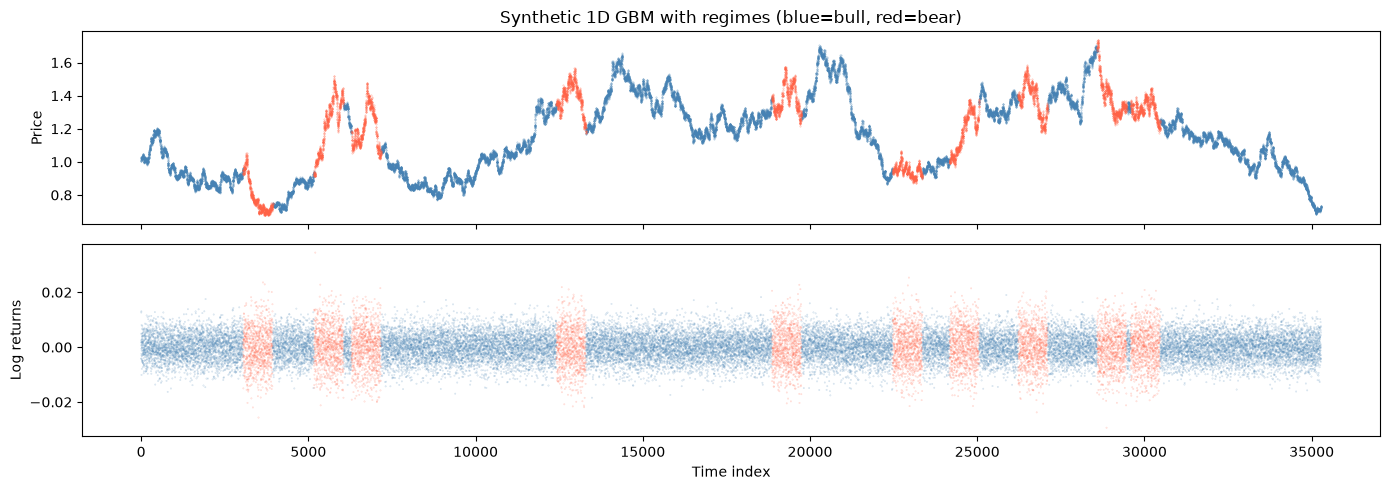

N=35280, Bull fraction: 75.00%


In [2]:
def generate_gbm_1d(n_years=20, obs_per_day=7, days_per_year=252, theta_bull=(0.02, 0.2), theta_bear=(-0.02, 0.3), n_bear_periods=10, bear_length_years=0.5, seed=14):
    """Generate 1D GBM with bullish/bearish regimes."""
    rng = np.random.default_rng(seed)
    N = n_years * days_per_year * obs_per_day
    dt = 1.0 / (days_per_year * obs_per_day)
    bear_len = int(bear_length_years * days_per_year * obs_per_day)
    
    # Place bearish periods randomly (non-overlapping)
    labels = np.zeros(N, dtype=int)  # 0=bull, 1=bear
    starts = []
    for _ in range(n_bear_periods):
        for _attempt in range(1000):
            s = rng.integers(0, N - bear_len)
            if all(abs(s - prev) >= bear_len for prev in starts):
                starts.append(s)
                break
        labels[s:s+bear_len] = 1
    
    # Generate returns
    mu_bull, sig_bull = theta_bull
    mu_bear, sig_bear = theta_bear
    returns = np.where(
        labels == 0,
        rng.normal((mu_bull - sig_bull**2/2)*dt, sig_bull*np.sqrt(dt), N),
        rng.normal((mu_bear - sig_bear**2/2)*dt, sig_bear*np.sqrt(dt), N),
    )
    prices = np.exp(np.cumsum(returns))
    return prices, returns, labels


prices_1d, returns_1d, true_labels_1d = generate_gbm_1d()

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
t = np.arange(len(prices_1d))
for regime in [0, 1]:
    mask = true_labels_1d == regime
    axes[0].scatter(t[mask], prices_1d[mask], s=0.1, 
                    c='steelblue' if regime==0 else 'tomato', alpha=0.5)
axes[0].set_ylabel('Price'); axes[0].set_title('Synthetic 1D GBM with regimes (blue=bull, red=bear)')
axes[1].scatter(t, returns_1d, s=0.1, c=np.where(true_labels_1d==0, 'steelblue', 'tomato'), alpha=0.3)
axes[1].set_ylabel('Log returns'); axes[1].set_xlabel('Time index')
plt.tight_layout(); plt.show()
print(f"N={len(returns_1d)}, Bull fraction: {(true_labels_1d==0).mean():.2%}")

The goal is then to classify these bear and bull regions correctly. As mentioned, in this notebook I look at methods of doing this given the entire time series data (unlabeled of course), not in a non-lookahead online/streaming manner.

Lets first give a quick walkthrough of the k-means clustering algorithm.
Given data $\{\mathbf{x}_1, \dots, \mathbf{x}_N\} \subset \mathbb{R}^d$ and a desired number of clusters $k$:

1. **Initialise** centroids $\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_k$ (e.g. randomly).
2. **Assign** each point to its nearest centroid: $\; c(i) = \arg\min_j \|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2$.
3. **Update** each centroid as the mean of its assigned points: $\; \boldsymbol{\mu}_j = \frac{1}{|C_j|}\sum_{i \in C_j} \mathbf{x}_i$.
4. **Repeat** steps 2–3 until assignments no longer change (or a max-iteration limit is reached).

The algorithm monotonically decreases the objective $J = \sum_{j=1}^{k}\sum_{i \in C_j}\|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2$ and converges to a local minimum. It is sensitive to initialisation, hence multiple restarts are common.


Lets now introduce two baseline models that we will compare Wasserstein k-means with: Rolling Moments k-means and Hidden Markov Model (HMM).

**Rolling Moments k-means** computes rolling moments (mean and variance) of the log-return series over a fixed window $w$ and cluster the resulting feature vectors with k-means. I don't know if there is a "standard" way of doing this but in my implementation the step by step looks like:

1. For each $t \ge w$, form the window $\mathbf{r}_t = (r_{t-w+1}, \dots, r_t)$ and compute:
$$\hat{\mu}_t = \frac{1}{w}\sum_{i=t-w+1}^{t} r_i, \qquad \hat{\sigma}_t = \sqrt{\frac{1}{w-1}\sum_{i=t-w+1}^{t}(r_i - \hat{\mu}_t)^2}$$

2. Construct $\mathbf{x}_t = (\hat{\mu}_t,\; \hat{\sigma}_t) \in \mathbb{R}^2$.

3. Apply k-means to the set $\{\mathbf{x}_t\}$, i.e. minimise the within-cluster sum of squares:
$$\min_{C_1, C_2} \sum_{j=1}^{k} \sum_{\mathbf{x}_t \in C_j} \|\mathbf{x}_t - \boldsymbol{\mu}_j\|^2 \text{, where } \boldsymbol{\mu}_j \text{ is the centroid of cluster } C_j.$$
    

4. Assign each $t$ a regime label from its cluster membership. Since k-means labels are arbitrary, we pick the label permutation that maximises accuracy.



**Hidden Markov Model (HMM)** models the returns as "being driven" from a latent Markov chain with $k$ hidden states, each associated with a Gaussian distribution.

**Mathematical formulation:**

- Hidden state sequence: $\{s_t\}_{t=1}^T$, with $s_t \in \{1, \ldots, k\}$.
- Transition matrix: $A_{ij} = P(s_{t+1}=j \mid s_t = i)$.
- Initial distribution: $\pi_i = P(s_1 = i)$.
- Emission model: $r_t \mid s_t = k \;\sim\; \mathcal{N}(\mu_k,\, \sigma_k^2)$.

**Steps:**

1. **Parameter estimation.** Maximise the incomplete-data (because we observe $r$ not $s$ it is incomplete-data) log-likelihood: $$\log P(\mathbf{r} \mid \theta) = \log \sum_{\mathbf{s}} P(\mathbf{r}, \mathbf{s} \mid \theta)$$ via the EM algorithm (which I wont cover).


2. **State decoding (Viterbi).** Find the most likely state path: $$\mathbf{s}^* = \arg\max_{\mathbf{s}} P(\mathbf{s} \mid \mathbf{r}, \theta)$$ (apparently) computed via dynamic programming in $\mathcal O(TK^2)$ time.

3. Assign regime labels from $\mathbf{s}^*$ and, as before, resolve label permutation against the ground truth.

We use 2 clusters for rolling moments k-means and 2 states for HMM.

In [3]:
from sklearn.cluster import KMeans
from hmmlearn.hmm import GaussianHMM

# --- 1. K-Means on rolling moments ---
window = 252  # ~1 month of intraday observations (252 = days_per_year * 1 day)
roll_mean = np.convolve(returns_1d, np.ones(window)/window, mode='valid')
roll_std = np.array([returns_1d[i:i+window].std() for i in range(len(returns_1d)-window+1)])

features = np.column_stack([roll_mean, roll_std])
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(features)
km_labels = kmeans.labels_

# Align with true labels (rolling window loses first window-1 points)
true_aligned = true_labels_1d[window-1:]

# K-Means labels are arbitrary (0/1 may be flipped) — pick best alignment
acc_km = max((km_labels == true_aligned).mean(), (km_labels != true_aligned).mean())
print(f"K-Means on moments accuracy: {acc_km:.2%}")

# --- 2. Hidden Markov Model ---
hmm = GaussianHMM(n_components=2, covariance_type='full', n_iter=200, random_state=42)
hmm.fit(returns_1d.reshape(-1, 1))
hmm_labels = hmm.predict(returns_1d.reshape(-1, 1))

acc_hmm = max((hmm_labels == true_labels_1d).mean(), (hmm_labels != true_labels_1d).mean())
print(f"HMM (2-state Gaussian) accuracy: {acc_hmm:.2%}")
print(f"\nHMM learned means: {hmm.means_.flatten()}")
print(f"HMM learned stds:  {np.sqrt(hmm.covars_.flatten())}")

K-Means on moments accuracy: 92.75%


Model is not converging.  Current: 135028.77035674723 is not greater than 135028.77516099575. Delta is -0.004804248514119536


HMM (2-state Gaussian) accuracy: 99.56%

HMM learned means: [-1.88211526e-06 -3.01332960e-05]
HMM learned stds:  [0.00477544 0.00722827]


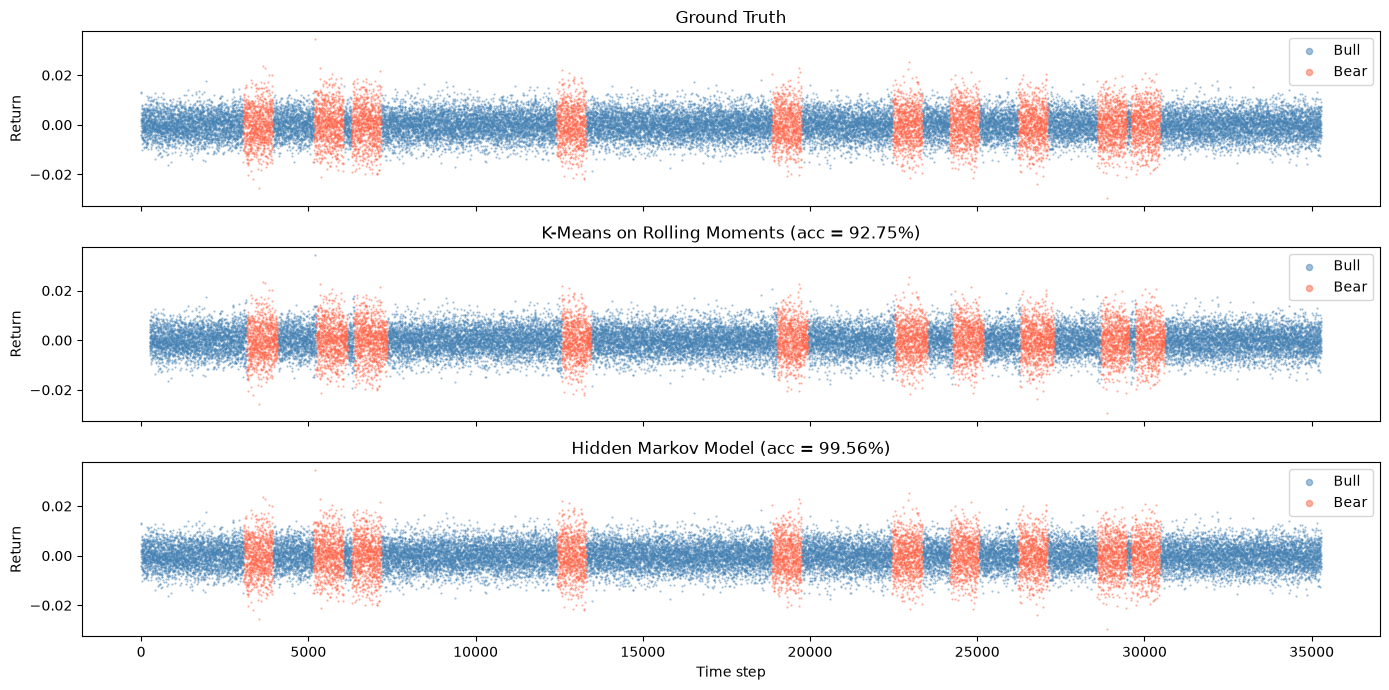

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

t_km = np.arange(window-1, len(returns_1d))  # time indices aligned with k-means output
t_full = np.arange(len(returns_1d))

# Flip labels if needed so colours match ground truth
if (km_labels != true_aligned).mean() > 0.5:
    km_labels = 1 - km_labels
if (hmm_labels != true_labels_1d).mean() > 0.5:
    hmm_labels = 1 - hmm_labels

colors = {0: 'steelblue', 1: 'tomato'}
regime_names = {0: 'Bull', 1: 'Bear'}

# --- Ground truth ---
for r in [0, 1]:
    mask = true_labels_1d == r
    axes[0].scatter(t_full[mask], returns_1d[mask], s=0.3, c=colors[r], alpha=0.5, label=regime_names[r])
axes[0].set_ylabel('Return')
axes[0].set_title('Ground Truth')
axes[0].legend(loc='upper right', markerscale=8)

# --- K-Means predictions ---
for r in [0, 1]:
    mask = km_labels == r
    axes[1].scatter(t_km[mask], returns_1d[window-1:][mask], s=0.3, c=colors[r], alpha=0.5, label=regime_names[r])
axes[1].set_ylabel('Return')
axes[1].set_title(f'K-Means on Rolling Moments (acc = {acc_km:.2%})')
axes[1].legend(loc='upper right', markerscale=8)

# --- HMM predictions ---
for r in [0, 1]:
    mask = hmm_labels == r
    axes[2].scatter(t_full[mask], returns_1d[mask], s=0.3, c=colors[r], alpha=0.5, label=regime_names[r])
axes[2].set_ylabel('Return')
axes[2].set_title(f'Hidden Markov Model (acc = {acc_hmm:.2%})')
axes[2].legend(loc='upper right', markerscale=8)
axes[2].set_xlabel('Time step')

plt.tight_layout()
plt.show()

Now for the main show.

The **Wasserstein distance**  quantifies the cost of optimally transporting mass from one probability distribution to another.


Let $(\mathcal{X}, d)$ be a metric space and let $\mu, \nu \in \mathbb{P}_p(\mathcal{X})$ be probability measures with finite $p$-th moment.

The $p$-Wasserstein distance is then defined (for $p \ge 1$) as:
$$W_p(\mu, \nu) = \left( \inf_{\gamma \in \Gamma(\mu,\nu)} \int_{\mathcal{X} \times \mathcal{X}} d(x,y)^p \, \mathrm{d}\gamma(x,y) \right)^{1/p}$$
where $\Gamma(\mu,\nu)$ is the set of all *couplings* (joint distributions) $\gamma$ on $\mathcal{X} \times \mathcal{X}$ with marginals $\mu$ and $\nu$.

**Intuition.** Think of $\mu$ as a pile of sand and $\nu$ as a hole to fill. $\gamma$ describes a *transport plan*: how much mass to move from $x$ to $y$. $W_p$ is the cost of the cheapest plan under ground metric $d$.

**Key properties:**
- $W_p$ is a true metric on $\mathcal{P}_p(\mathcal{X})$ (non-negative, symmetric, satisfies the triangle inequality, and $W_p(\mu,\nu)=0 \iff \mu=\nu$).
- Convergence in $W_p$ is equivalent to weak convergence plus convergence of $p$-th moments.

**1-D closed form.** When $\mathcal{X} = \mathbb{R}$ and $p=1$, the distance simplifies to:
$$W_1(\mu, \nu) = \int_0^1 |F_\mu^{-1}(q) - F_\nu^{-1}(q)|\, \mathrm{d}q$$
where $F^{-1}$ denotes the quantile function. For general $p$:
$$W_p^p(\mu, \nu) = \int_0^1 |F_\mu^{-1}(q) - F_\nu^{-1}(q)|^p\, \mathrm{d}q$$
This makes 1-D Wasserstein computations very cheap — just sort the samples.

**Discrete (empirical) case.** For empirical measures $\mu = \frac{1}{n}\sum_{i=1}^n \delta_{x_i}$ and $\nu = \frac{1}{n}\sum_{j=1}^n \delta_{y_j}$ with equal mass, $W_p^p$ reduces to a minimum-cost matching. In 1-D this is solved by sorting both samples and pairing them in order:
$$W_p^p(\mu, \nu) = \frac{1}{n}\sum_{i=1}^n |x_{(i)} - y_{(i)}|^p$$
where $x_{(i)}, y_{(i)}$ are the order statistics.